# Thoracic Disease Classification from Chest X-Rays

Multi-class classification of chest X-ray images into **20 thoracic pathology classes** (including *No Finding*), evaluated on a held-out Kaggle test set of 17,015 images.

| | |
|---|---|
| **Model** | DenseNet-201 (ImageNet-pretrained via `timm`), fine-tuned end-to-end |
| **Data** | 51,043 labelled training images · 17,015 test images |
| **Imbalance handling** | Class-balanced `WeightedRandomSampler` + Focal Loss (γ = 2) |
| **Metric** | Macro-averaged asymmetric cost (TP = +1, FP = −1, FN = −5) |
| **Validation score** | −5.3045 (argmax) → **−5.2469** after per-class threshold tuning |
| **Held-out test set** | **−5.04455** (public split) · **−5.33888** (private split) |

**Pipeline:** load data → explore class imbalance → stratified split → augmentation → class-balanced sampling → focal-loss fine-tuning with discriminative learning rates → per-class threshold tuning on the evaluation metric → inference → submission.

## 1. Setup

Libraries: PyTorch + `timm` for the model, torchvision for augmentation, scikit-learn for the stratified split.

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Free memory before training
import gc
gc.collect()
torch.cuda.empty_cache()

In [4]:
# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # faster convolutions for fixed-size inputs
torch.cuda.empty_cache()

print("Using:-", device)

Using:- cuda


## 2. Load the data

`train.csv` holds an image `id` and 20 one-hot label columns (exactly one `1` per row). The one-hot vector is converted to a single integer class index with `argmax`.

In [5]:
# Load data
train_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

label_cols = train_df.columns[1:]
print(label_cols)

# One-hot labels -> single class index (0-19)
train_df["label"] = train_df[label_cols].values.argmax(axis=1)

Index(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
       'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
       'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum',
       'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta',
       'Calcification of the Aorta', 'No Finding'],
      dtype='object')


## 3. Class distribution

The dataset is heavily imbalanced: **No Finding** accounts for roughly two-thirds of all images, while classes such as Hernia, Pneumomediastinum and Subcutaneous Emphysema have very few examples. Because the metric is **macro-averaged**, every class counts equally — so rare classes matter as much as common ones.

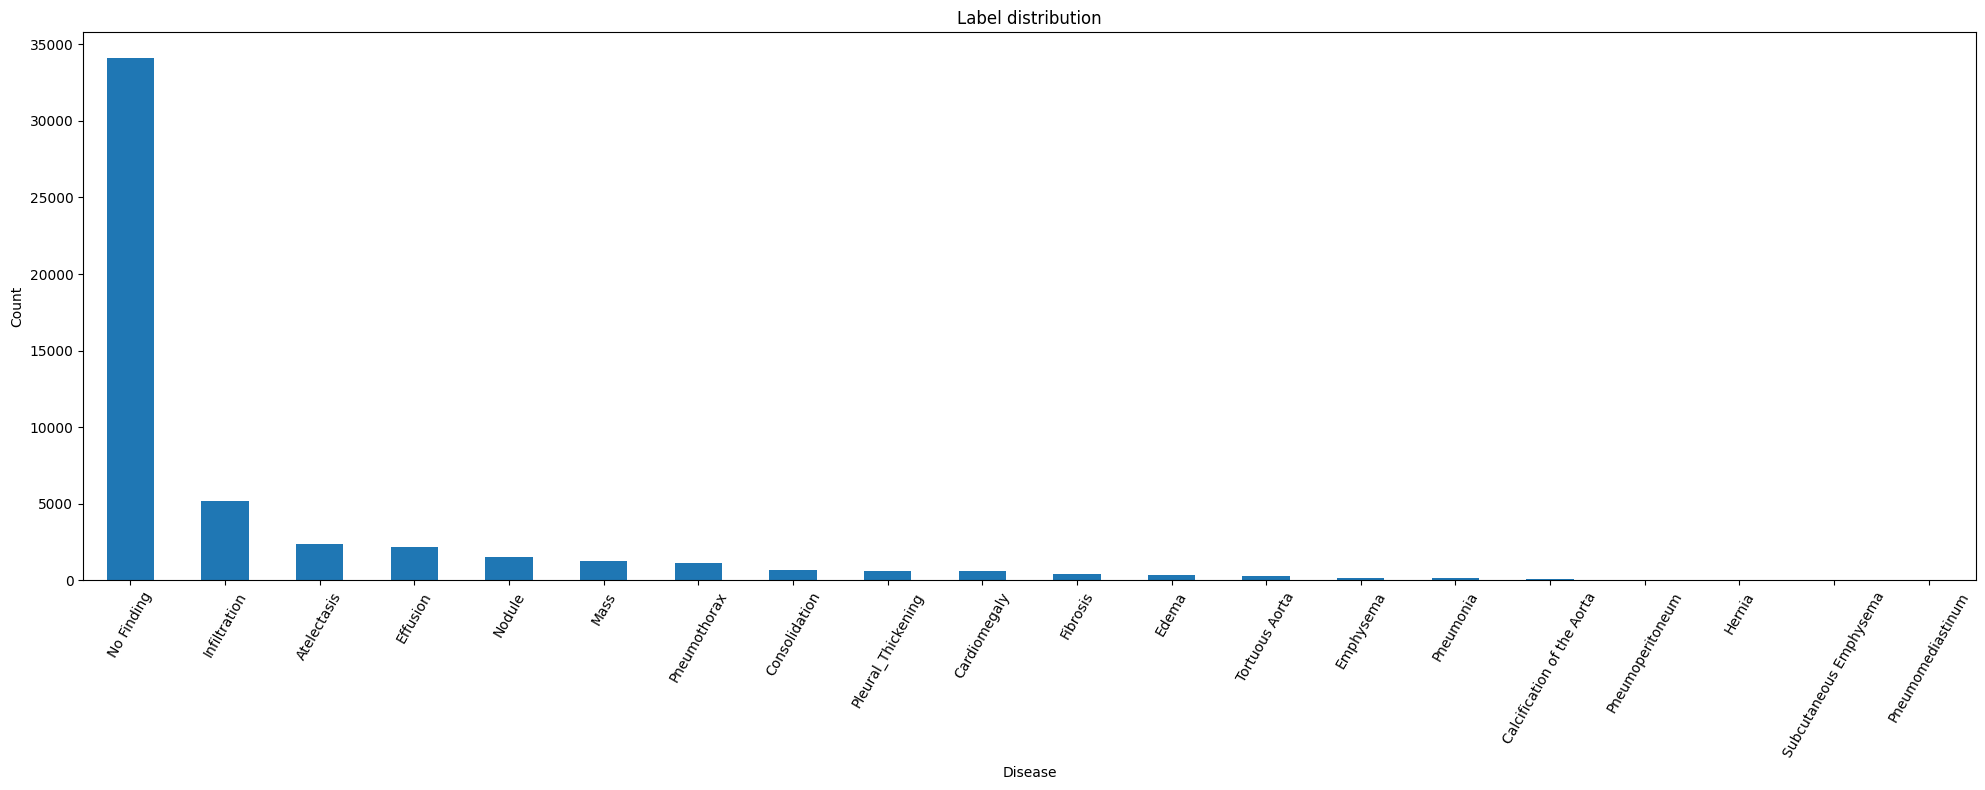

In [6]:
# Distribution of labels
label_map = dict(enumerate(label_cols))

train_df["label_name"] = train_df["label"].map(label_map)

label_count = train_df["label_name"].value_counts()

plt.figure(figsize=(20, 8))
label_count.plot(kind='bar')
plt.title("Label distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

## 4. Train / validation split

A **stratified 90/10 split** keeps the same class proportions in both sets, so even rare classes appear in validation.

In [7]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42,
)

## 5. Dataset

Loads each X-ray as RGB (to match ImageNet-pretrained weights). Test items return the image name instead of a label so predictions can be written back by `id`.

In [8]:
class XrayDataset(Dataset):

    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["id"]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_name
        else:
            label = self.df.iloc[idx]["label"]
            return image, label

## 6. Augmentation

- **Train:** resize to 256 → random 224 crop, horizontal flip, ±15° rotation, colour jitter.
- **Validation / test:** resize to 256 → centre 224 crop.
- Both use ImageNet normalisation statistics.

In [9]:
# ImageNet normalisation statistics
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

## 7. Data loaders with class-balanced sampling

Each training image is sampled with weight $1 / n_c$, where $n_c$ is the number of images in its class. Batches therefore see rare pathologies about as often as common ones, instead of being dominated by *No Finding*.

In [10]:
img_dir = "/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images"

train_dataset = XrayDataset(train_df, img_dir, train_transform)
val_dataset   = XrayDataset(val_df, img_dir, val_transform)
test_dataset  = XrayDataset(test_df, img_dir, val_transform, is_test=True)

# Class-balanced sampling: weight each image by 1 / (size of its class)
counts = Counter(train_df["label"])
sample_weights = torch.tensor(
    [1.0 / counts[int(train_df.iloc[i]["label"])] for i in range(len(train_df))],
    dtype=torch.float32
)
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = 32,
    sampler     = sampler,
    num_workers = 4,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True
)

## 8. Focal Loss

Focal loss down-weights easy, confidently classified examples so training focuses on hard ones:

$$
\mathrm{FL}(p_t) = -(1 - p_t)^{\gamma}\,\log(p_t), \qquad \gamma = 2
$$

where $p_t$ is the predicted probability of the true class. An optional per-class `alpha` is supported but not used here, since the sampler already balances classes.

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt      = torch.exp(-ce_loss)            # probability of the true class
        loss    = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()

## 9. Evaluation metric

Missing a disease is penalised five times more than a false alarm. For each class $c$:

$$
\text{Score}_c = \frac{TP_c - FP_c - 5 \cdot FN_c}{N_c}
$$

and the final score is the macro-average over all classes:

$$
\text{Final Score} = \frac{1}{C} \sum_{c=1}^{C} \text{Score}_c
$$

This function reproduces the metric locally so that model selection and threshold tuning optimise exactly what the test evaluation measures.

In [12]:
# Evaluation metric (macro-averaged asymmetric cost)
def custom_score(y_true, y_pred):
    y_true       = np.array(y_true)
    y_pred       = np.array(y_pred)
    score        = 0
    count_classes = 0
    for c in range(20):
        TP = np.sum((y_pred == c) & (y_true == c))
        FP = np.sum((y_pred == c) & (y_true != c))
        FN = np.sum((y_pred != c) & (y_true == c))
        N  = np.sum(y_true == c)
        if N == 0:
            continue
        score        += (TP - FP - 5 * FN) / N
        count_classes += 1
    return score / count_classes

Quick sanity check that the test dataset returns `(tensor, image name)`:

In [13]:
img, name = test_dataset[0]
print(type(img), name)

<class 'torch.Tensor'> 7b647fbfcc874a7084a4470fc150e267.png


## 10. Training function

- **Backbone:** any `timm` model, ImageNet-pretrained, with a new 20-class head.
- **Discriminative learning rates (AdamW):** `1e-3` for the new classifier head, `1e-5` for the pretrained body — the head learns fast while pretrained features are only gently adjusted.
- **Cosine annealing** learning-rate schedule, **gradient clipping** at norm 1.0.
- After every epoch the model is scored on validation with the evaluation metric, and the **best epoch's weights** are kept.

In [14]:
def train_model(model_name, epochs=15):
    print(f"\nTraining {model_name}")
    model = timm.create_model(model_name, pretrained=True, num_classes=20)
    model.to(device)

    # Split parameters: new classifier head vs. pretrained body
    head_params = list(model.get_classifier().parameters())
    head_ids    = {id(p) for p in head_params}
    body_params = [p for p in model.parameters() if id(p) not in head_ids]

    optimizer = optim.AdamW([
        {"params": head_params,  "lr": 1e-3},
        {"params": body_params,  "lr": 1e-5},
    ], weight_decay=1e-4)

    criterion = FocalLoss(alpha=None, gamma=2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_score = -999
    best_state = None

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        # ---- validate with the evaluation metric ----
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                preds  = model(images).argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        score = custom_score(val_labels, val_preds)
        print(f"  Epoch {epoch+1} → score: {score:.4f}")

        # keep the best epoch
        if score > best_score:
            best_score = score
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"{model_name} best score: {best_score:.4f}")
    return model, best_score

## 11. Train DenseNet-201

15 epochs at roughly 13 minutes per epoch on a Kaggle GPU. The validation score improves from −9.42 after epoch 1 to a best of **−5.3045** at epoch 14.

In [15]:
dense_model, dense_score = train_model("densenet201")


Training densenet201


Epoch 1/15: 100%|██████████| 1436/1436 [13:02<00:00,  1.84it/s]


  Epoch 1 → score: -9.4228


Epoch 2/15: 100%|██████████| 1436/1436 [12:55<00:00,  1.85it/s]


  Epoch 2 → score: -6.4948


...

  Epoch 13 → score: -5.4062


Epoch 14/15: 100%|██████████| 1436/1436 [12:53<00:00,  1.86it/s]


  Epoch 14 → score: -5.3045


Epoch 15/15: 100%|██████████| 1436/1436 [12:54<00:00,  1.85it/s]


  Epoch 15 → score: -5.3841
densenet201 best score: -5.3045


In [16]:
best_model = dense_model
print(f"Best model: DenseNet201 with score {dense_score:.4f}")

Best model: DenseNet201 with score -5.3045


## 12. Per-class threshold tuning

Plain `argmax` treats every class the same, but the metric punishes missed diseases heavily. For each class, a threshold between 0.30 and 0.95 is searched on the validation set to maximise that class's score. At prediction time, class probabilities are divided by their thresholds before `argmax`, which favours classes with lower thresholds.

The tuned thresholds are only used if they improve the overall validation score. Here they do: **−5.3045 → −5.2469**.

In [17]:
def get_val_probs(model):
    model.eval()
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            probs  = torch.softmax(model(images), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.extend(labels.numpy())
    return np.vstack(all_probs), np.array(all_labels)


def find_best_thresholds(val_probs, val_labels, n_classes=20):
    thresholds = np.ones(n_classes) * 0.5
    for c in range(n_classes):
        best_t, best_score = 0.5, -999
        c_probs = val_probs[:, c]
        for t in np.arange(0.30, 0.95, 0.01):
            preds = val_probs.argmax(axis=1).copy()
            preds[c_probs >= t] = c
            TP = np.sum((preds == c) & (val_labels == c))
            FP = np.sum((preds == c) & (val_labels != c))
            FN = np.sum((preds != c) & (val_labels == c))
            N  = np.sum(val_labels == c)
            if N == 0:
                continue
            s = (TP - FP - 5 * FN) / N
            if s > best_score:
                best_score, best_t = s, t
        thresholds[c] = best_t
        print(f"  Class {c:2d} ({label_cols[c]:35s}) t={best_t:.2f}  score={best_score:.3f}")
    return thresholds


print("\nFinding per-class thresholds...")
val_probs, val_labels_arr = get_val_probs(best_model)
best_thresholds = find_best_thresholds(val_probs, val_labels_arr)

# Checking for improvement
val_preds_tuned = (val_probs/best_thresholds[np.newaxis,:]).argmax(axis=1)
tuned_score     = custom_score(val_labels_arr, val_preds_tuned)
raw_score       = custom_score(val_labels_arr, val_probs.argmax(axis=1))
print(f"\nVal score raw:   {raw_score:.4f}")
print(f"Val score tuned: {tuned_score:.4f}")

# Use tuned thresholds if better, else raw
if tuned_score > raw_score:
    use_thresholds = best_thresholds
    print("Using tuned thresholds")
else:
    use_thresholds = np.ones(20) * 0.5
    print("Tuning didn't help — using flat thresholds")


Finding per-class thresholds...
  Class  0 (Atelectasis                        ) t=0.43  score=-4.447
  Class  1 (Cardiomegaly                       ) t=0.30  score=-4.667
  Class  2 (Consolidation                      ) t=0.41  score=-6.092
  Class  3 (Edema                              ) t=0.38  score=-5.303
  Class  4 (Effusion                           ) t=0.40  score=-3.319
  Class  5 (Emphysema                          ) t=0.31  score=-7.176
  Class  6 (Fibrosis                           ) t=0.38  score=-5.949
  Class  7 (Hernia                             ) t=0.30  score=-7.250
  Class  8 (Infiltration                       ) t=0.41  score=-4.764
  Class  9 (Mass                               ) t=0.34  score=-4.864
  Class 10 (Nodule                             ) t=0.45  score=-6.294
  Class 11 (Pleural_Thickening                 ) t=0.35  score=-6.066
  Class 12 (Pneumonia                          ) t=0.30  score=-5.625
  Class 13 (Pneumothorax                       ) t=0.36  

## 13. Inference on the test set

In [18]:
best_model.eval()
predictions = []
test_ids    = []

with torch.no_grad():
    for images, ids in test_loader:
        images   = images.to(device)
        probs    = torch.softmax(best_model(images), dim=1).cpu().numpy()
        adjusted = probs / use_thresholds[np.newaxis, :]  # apply per-class thresholds
        preds    = adjusted.argmax(axis=1)
        predictions.extend(preds)
        test_ids.extend(ids)

## 14. Submission file

Predictions are written back to the one-hot format of `sample_submission.csv`. The assertions check that every row has exactly one positive class and that every test image has a prediction.

In [19]:
submission = pd.DataFrame()
submission["id"] = test_ids
for col in label_cols:
    submission[col] = 0
for i, pred in enumerate(predictions):
    submission.loc[i, label_cols[int(pred)]] = 1

assert (submission[label_cols].sum(axis=1) == 1).all(), "Row check failed!"
assert len(predictions) == len(test_df)
submission.to_csv("submission.csv", index=False)

## Results

| Stage | Score |
|---|---:|
| Validation, argmax (best epoch) | −5.3045 |
| Validation, tuned thresholds | −5.2469 |
| Held-out test set, public split | −5.04455 |
| Held-out test set, private split | −5.33888 |

Higher is better; a perfect model would score +1.

**Notes and limitations**

- The same validation split is used both to pick the best epoch and to tune thresholds, so the validation score is slightly optimistic.
- Thresholds are searched one class at a time, then applied jointly by dividing probabilities by the thresholds; they are a heuristic rather than a joint optimum.
- No random seed is fixed for sampling and augmentation, so exact scores can vary between runs.
- Possible next steps: higher input resolution, test-time augmentation, ensembling several backbones, and cross-validated threshold tuning.